# Supervised Machine Learning: regression and its metrics
Regression in machine learning is a technique used when the label we want to predict is a continuous variable rather than a category. The key difference in how these regression models work comes from the fact that we now care about how *close* our predictions are instead of how often they perfectly match. In simple terms, this amounts to finding the best-fitting line through a scatter plot of data points. This line can then be used to predict the label (the height on the y-axis in the visual below) for new data based on the predictor features (the x-axis in the visual below). For example, if you want to predict the mileage of a car based on its features like weight, horsepower, and displacement, you could use regression. You would plot the average MPG of each car given its features, then use regression to find the relationship between MPG and the features. This relationship can then be used to predict the MPG of other cars based on their features.

We can get a sense of how the problem changes when we move to regression by visualizing what overfitting looks like for regression tasks:<br><br>
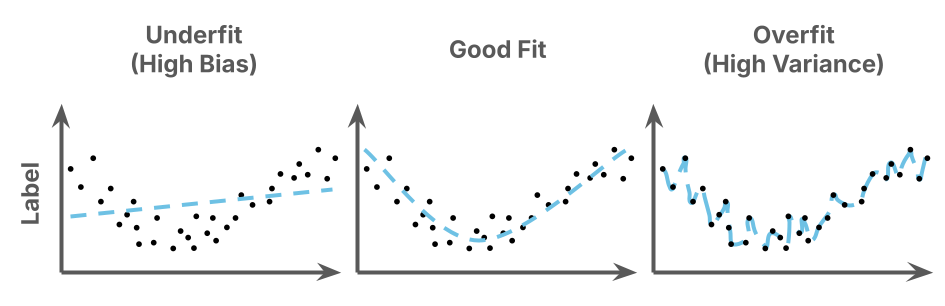

---
## 1.&nbsp;Import libraries and files 💾
For this workshop, we'll be using the diamonds dataset from seaborn, which contains information on diamond prices and their attributes, such as carat, cut, color, and clarity.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor

---
## 2.&nbsp;The diamond dataset 💎
The dataset provides detailed information about a collection of nearly 54,000 round-cut diamonds. It includes various attributes of each diamond, such as its cut quality, clarity, color, depth, table, price, and dimensions (x, y, z).

* price: price in US dollars
* carat: weight of the diamond
* cut: quality of the cut
* color: diamond colour
* clarity: a measurement of how clear the diamond is
* x: length in mm
* y: width in mm
* z: depth in mm
* depth: total depth percentage
* table: width of top of diamond relative to widest point

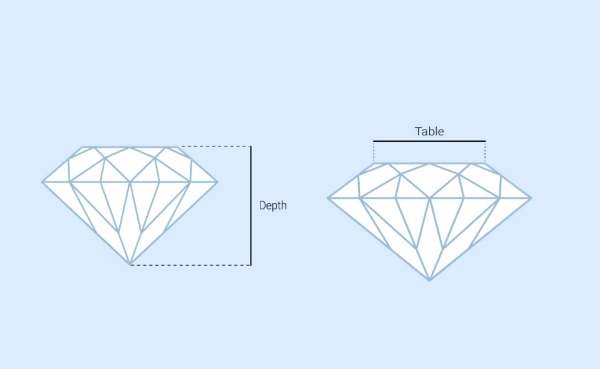


Our goal will be to predict the price of a diamond based on these attributes. Let's start by loading the dataset and exploring its structure.

In [2]:
diamonds = sns.load_dataset('diamonds')

In [3]:
diamonds.shape

(53940, 10)

Before we look at the dataset, we'll have to hide the testing data

In [4]:
X = diamonds.copy()
y = X.pop('price')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = X_train.copy()
train_data['price'] = y_train

To get a sense of the dataset, let's take a look at the first few rows using the head method:

In [5]:
train_data.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
26546,2.01,Good,F,SI2,58.1,64.0,8.23,8.19,4.77,16231
9159,1.01,Very Good,E,SI2,60.0,60.0,6.57,6.49,3.92,4540
14131,1.10,Premium,H,VS2,62.5,58.0,6.59,6.54,4.10,5729
15757,1.50,Good,E,SI2,61.5,65.0,7.21,7.17,4.42,6300
24632,1.52,Very Good,G,VS1,62.1,57.0,7.27,7.32,4.53,12968


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43152 entries, 26546 to 15795
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    43152 non-null  float64 
 1   cut      43152 non-null  category
 2   color    43152 non-null  category
 3   clarity  43152 non-null  category
 4   depth    43152 non-null  float64 
 5   table    43152 non-null  float64 
 6   x        43152 non-null  float64 
 7   y        43152 non-null  float64 
 8   z        43152 non-null  float64 
 9   price    43152 non-null  int64   
dtypes: category(3), float64(6), int64(1)
memory usage: 2.8 MB


In [7]:
train_data.describe()

,carat,depth,table,x,y,z,price
count,43152.000000,43152.000000,43152.000000,43152.000000,43152.000000,43152.000000,43152.000000
mean,0.798233,61.743046,57.459548,5.732607,5.736434,3.539256,3939.490707
std,0.473342,1.428243,2.229325,1.120196,1.147500,0.708062,3990.000962
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.720000,4.730000,2.910000,956.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5354.250000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18818.000000


---
## 3. Creating a baseline model 🤖
Prior experience leads me to believe that the carat of a diamond can influence its price. Let's look at the relationship between the carat and price columns to see if that's true.

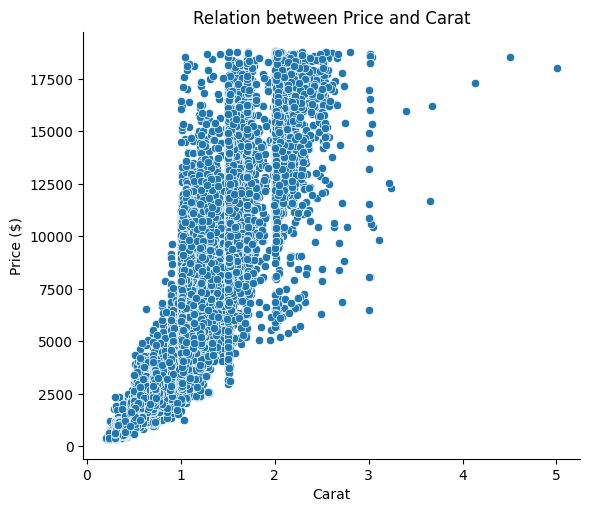

In [8]:
(
  sns.relplot(data=train_data,
              x='carat',
              y='price',
              height=5,
              aspect=1.2)
  .set(title='Relation between Price and Carat')
  .set_axis_labels('Carat', 'Price ($)')
);

Looking at our plot of the relationship between carat and price, we can come up with a simple baseline model based on a linear relationship between the two variables. For example, we can assume that the price of a diamond is roughly 6,000 times its carat weight. This would give us a simple model like:

`price = carat * 6000`

Let's plot a line on the chart to see how carat * 6000 would look

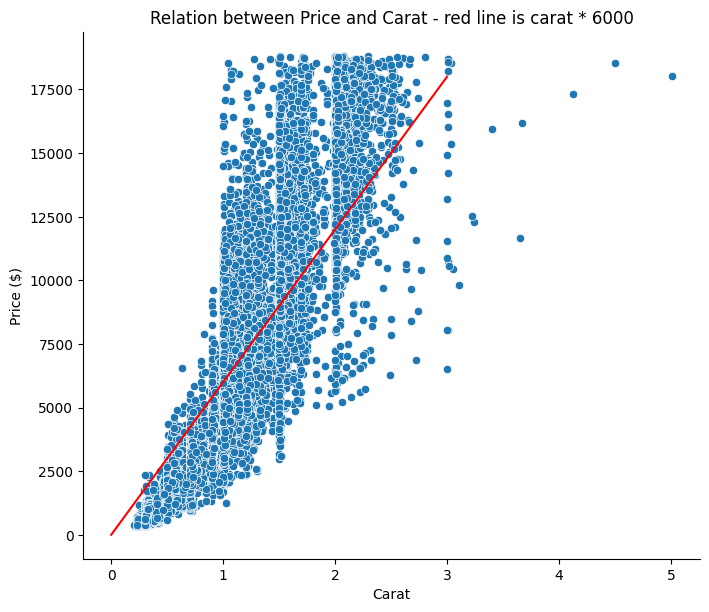

In [9]:
(
  sns.relplot(data=train_data,
              x='carat',
              y='price',
              height=6,
              aspect=1.2)
  .set(title='Relation between Price and Carat - red line is carat * 6000')
  .set_axis_labels('Carat', 'Price ($)')
)
plt.plot([0, 3], [0, 18000], 'r-')
plt.show();

This appears to be a decent fit for our baseline model. However, assessing its performance becomes a different challenge compared to classification tasks. In classification, we can easily determine how well our model performs by checking if it correctly predicts the categories. But with regression, where our predictions involve continuous values like prices, they don't fall into distinct categories. Hence, we must employ alternative techniques to evaluate the effectiveness of our regression model.

First, let's create our rule-based baseline model as a function so we can use it.

In [10]:
def baseline_model(X):
  """Makes price predictions based on carat alone to set a baseline
  Parameters:
    X: df of predictor features
  Returns
    price_pred: series of price predictions
  """
  price_pred = X['carat'] * 6000
  return price_pred

Now let's make predictions for the test set using our baseline model.

In [11]:
baseline_test_pred = baseline_model(X_test)

In [12]:
baseline_test_pred

,carat
1388,1440.0
50052,3480.0
41645,2400.0
42377,2580.0
17244,9300.0
...,...
44081,3000.0
23713,1500.0
31375,1860.0
21772,7380.0


Now that we have our predictions for the test set, we can evaluate how good (or bad) these predictions are.

---
## 4.&nbsp;Assessing a regression model with Scikit-Learn 📈

Metrics serve as quantitative measures to evaluate the model's prediction accuracy compared to the actual target values. The choice of a metric depends on the specific regression task and data nature. Selecting the right metric beforehand is vital for guiding model development, tuning hyperparameters, and making decisions about feature engineering and model architecture. While it's recommended to have one primary evaluation metric as your main goal, examining multiple metrics provides valuable insights into the model's strengths and weaknesses. Here, we'll explore four common metrics to gain a better understanding of their calculations and meanings.

- For a comprehensive list of metrics, check [here](https://scikit-learn.org/stable/modules/classes.html?highlight=metrics#module-sklearn.metrics).
- To understand each regression metric and when to use them, refer to this [guide](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics).

### 4.1. Mean Absolute Error

**Mean Absolute Error (MAE):**
- **Description**: This is the most intuitive measure. It is the average distance the model's predictions are from the actual values. "Absolute" comes from "absolute value" because whether the error is negative or positive (underpredicting or overpredicting) is irrelevant, we just care how far off it is.
- **Strengths**: The primary benefit of using MAE is how interpretable it is. To say, for instance, that our model is on average \$1000 off in its housing price predictions is very easy to understand.
- **Weaknesses**: Its not immediately obvious whether the model is doing well or poorly because the meaning of this number changes depending on the context. \$100 off when predicting the cost of a house is great but the same MAE when predicting the cost of ice cream is abysmal. MAE also misses out on some of the strengths of other metrics, as elaborated below.
- **Applied Domains**: MAE is often used in finance because of the interpretability of the exact dollar amounts it calculates.

In [13]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_true = y_test,
    y_pred = baseline_test_pred
)

baseline_mae

1639.666295884316

### 4.2. Root Mean Square Error


**Root Mean Squared Error (RMSE):**
- **Description**: Takes the square root of the mean squared error, compressing it down to a number that is more interpretable.
- **Strengths**: While RMSE is not differentiable itself, optimizing MSE automatically optimizes RMSE allowing us to use methods like gradient descent to optimize it indirectly. Unlike MSE, RMSE is in units we can make sense of ("this many dollars off"), although its meaning is still not quite as straightforward as MAE.
- **Weaknesses**: Like with MSE, squaring the error increases the effect of outliers, potentially leading to models overfitting them.
- **Applied Domains**: RMSE is popular in certain scientific domains like environmental science and meteorology where differentiability and interpretability are both needed.

In [14]:
from sklearn.metrics import root_mean_squared_error

baseline_rmse = root_mean_squared_error(
    y_true = y_test,
    y_pred = baseline_test_pred
)

baseline_rmse

1956.2807655420934

### 4.3. Mean Absolute Percentage

**Mean Absolute Percentage Error (MAPE):**
- **Description**: Measures the percentage off each prediction is and takes the average of those percentages. This allows us to say things like, "on average, the model's predictions were 3% off of the true values."
- **Strengths**: The measure is intuitive and easily interpreted. It also maintains the same meaning across contexts so the successfulness of models predicting two different things can be compared.
- **Weaknesses**: MAPE should not be used when the labels can include 0s as this will break the calculation.
- **Applied Domains**: MAPE is popular in business for its intuitive meaning that is easy to communicate to various stakeholders.

In [15]:
from sklearn.metrics import mean_absolute_percentage_error

baseline_mape = mean_absolute_percentage_error(
    y_true = y_test,
    y_pred = baseline_test_pred
)

baseline_mape

0.9384528370170875

### 4.4. R-Squared 🧮


**R<sup>2</sup> (R-Squared)**
- **Description**: Unlike these other measures, R-squared is not technically a measure of error but of "goodness-of-fit" or "explanatory power". It measures how much of the target feature's variance can be explained by the model. One way to think of it intuitively is to imagine that there is some set of reasons why every data point has the values it does. If we could account for all of those reasons perfectly, none of the variance would be left unexplained and we could perfectly predict all of the data. This would acheive an R-squared of 1.0. For contrast, a model that predicts the average of the data for every observation would have an R-squared of 0 (meaning 0 explanatory power because it does not use the predictor features at all) and models with even worse predictions than this can result in negative R-squared values.
- **Strengths**: Like MAPE, the meaning of different values of R-squared is retained across domains: 1.0 always represents a perfect model.
- **Weaknesses**: R-squared is "unitless" so we can no longer talk about things like dollar amounts. This makes it hard for non-technical audiences to understand.
- **Applied Domains**: R-squared is frequently used in economics and the social and natural sciences due to its interpretability as the "explanatory power" of the model. In these technical contexts the meaning of its possible values are widely-understood.

In [16]:
from sklearn.metrics import r2_score

baseline_r2 = r2_score(
    y_true = y_test,
    y_pred = baseline_test_pred
)

baseline_r2

0.759257884013869

In [17]:
# Defining function for computing many scores at once
def score_model(model_name, y_true, y_pred):
  scores = {
      'Model': model_name,
      'MAE ($)': round(mean_absolute_error(y_true, y_pred), 2),
      'RMSE ($)': round(root_mean_squared_error(y_true, y_pred), 2),
      'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true, y_pred), 2),
      'R-Squared': round(r2_score(y_true, y_pred), 3)
  }
  return scores

# Setting up list for score comparisons
model_scores = []

In [18]:
model_scores.append(score_model('Baseline Model', y_test, baseline_test_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,1639.67,1956.28,93.85,0.759


---
## 5. Creating a Scikit-Learn model 🧠
Scikit-Learn has a great [guide for models](https://scikit-learn.org/1.3/tutorial/machine_learning_map/index.html#).

First off, before we do anything with models, we'll set up a preprocessor.

In [19]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43152 entries, 26546 to 15795
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    43152 non-null  float64 
 1   cut      43152 non-null  category
 2   color    43152 non-null  category
 3   clarity  43152 non-null  category
 4   depth    43152 non-null  float64 
 5   table    43152 non-null  float64 
 6   x        43152 non-null  float64 
 7   y        43152 non-null  float64 
 8   z        43152 non-null  float64 
 9   price    43152 non-null  int64   
dtypes: category(3), float64(6), int64(1)
memory usage: 3.8 MB


In [20]:
X_cat = X_train.select_dtypes(exclude = 'number').columns
X_num = X_train.select_dtypes(include = 'number').columns

cut = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color = ['D','E','F','G','H','I','J']
clarity = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

preprocessor = make_column_transformer(
    (OrdinalEncoder(categories=[cut, color, clarity]), X_cat),
    ("passthrough", X_num)
)

In [21]:
preprocessor

ColumnTransformer(transformers=[('ordinalencoder',
                                 OrdinalEncoder(categories=[['Fair', 'Good',
                                                             'Very Good',
                                                             'Premium',
                                                             'Ideal'],
                                                            ['D', 'E', 'F', 'G',
                                                             'H', 'I', 'J'],
                                                            ['I1', 'SI2', 'SI1',
                                                             'VS2', 'VS1',
                                                             'VVS2', 'VVS1',
                                                             'IF']]),
                                 Index(['cut', 'color', 'clarity'], dtype='object')),
                                ('passthrough', 'passthrough',
                                 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))])

### 5.1.&nbsp;DecisionTreeRegressor

Step-by-Step Process:

1. **Start with All Data:** Begin with the entire dataset.
2. **Find the Best Split:** Look for the feature and value that best splits the data into two groups to minimize prediction errors.
3. **Create Branches:** Split the data based on the best feature and value.
4. **Repeat:** Apply the same process recursively on each branch to create further splits until a stopping condition is met (like a maximum tree depth or minimum data points in a leaf).
5. **Make Predictions:** For a new data point, follow the decision rules down the branches of the tree to reach a leaf node, and predict the average value of the training data that landed in that node.

In [22]:
dt_pipeline = make_pipeline(
    preprocessor,
    DecisionTreeRegressor(random_state=42)
)

dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Fair',
                                                                              'Good',
                                                                              'Very '
                                                                              'Good',
                                                                              'Premium',
                                                                              'Ideal'],
                                                                             ['D',
                                                                              'E',
                                                                              'F',
                                                                              'G',
                                                                              'H',
                                                                              'I',
                                                                              'J'],
                                                                             ['I1',
                                                                              'SI2',
                                                                              'SI1',
                                                                              'VS2',
                                                                              'VS1',
                                                                              'VVS2',
                                                                              'VVS1',
                                                                              'IF']]),
                                                  Index(['cut', 'color', 'clarity'], dtype='object')),
                                                 ('passthrough', 'passthrough',
                                                  Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

Predicting with the DecisionTreeRegressor

In [23]:
dt_predictions = dt_pipeline.predict(X_test)

How well is the DecisionTreeRegressor performing? Let's compare the R-squared with our baseline model

In [24]:
model_scores.append(score_model('Decision Tree', y_test, dt_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,1639.67,1956.28,93.85,0.759
1,Decision Tree,349.99,724.07,8.34,0.967


That's a big improvement! Let's see how a few other models perform.

### 5.2.&nbsp;SGDRegressor

Step-by-Step Process:

1. **Initialize Weights:** Start with random values for the model’s parameters (weights).
2. **Choose a Data Batch:** Pick a small, random subset of the training data.
3. **Calculate Error:** Use the current weights to make predictions and calculate the difference between predicted and actual values (error).
4. **Update Weights:** Adjust the weights slightly in the direction that reduces the error based on the gradient of the error with respect to the weights.
5. **Repeat:** Continue selecting new batches and updating weights until the model’s performance stabilizes or a set number of iterations is reached.
6. **Make Predictions:** Use the final weights to predict values for new data.

In [25]:
sgd_pipeline = make_pipeline(
    preprocessor,
    StandardScaler(),
    SGDRegressor(random_state=42)
)

sgd_pipeline.fit(X_train, y_train)

sgd_predictions = sgd_pipeline.predict(X_test)

In [26]:
model_scores.append(score_model('Stochastic Gradient Descent', y_test, sgd_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,1639.67,1956.28,93.85,0.759
1,Decision Tree,349.99,724.07,8.34,0.967
2,Stochastic Gradient Descent,804.43,1225.14,44.61,0.906


### 5.3.&nbsp;LinearRegression

1. **Assume a Model:** Start with a linear equation of the form: 𝑦 = weights × features + bias
2. **Fit the Line:** Adjust the weights and bias to find the line that best fits the data points.
3. **Calculate Predictions:** Use the current weights and bias to predict values for the training data.
4. **Measure Error:** Find the difference between predicted values and actual values.
5. **Adjust Parameters:** Update weights and bias to minimize the error.
6. **Optimize Line:** Repeat adjusting weights and bias until the line best fits the data points.
7. **Make Predictions:** Use the final line equation to predict values for new data.

In [27]:
lr_pipeline = make_pipeline(
    preprocessor,
    StandardScaler(),
    LinearRegression()
)

lr_pipeline.fit(X_train, y_train)

lr_predictions = lr_pipeline.predict(X_test)

In [28]:
model_scores.append(score_model('Linear Regression', y_test, lr_predictions))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model,1639.67,1956.28,93.85,0.759
1,Decision Tree,349.99,724.07,8.34,0.967
2,Stochastic Gradient Descent,804.43,1225.14,44.61,0.906
3,Linear Regression,805.27,1224.60,44.57,0.906


---
## 6.&nbsp;Comparing our Scikit-Learn models 🔍

<Axes: xlabel='R-Squared', ylabel='Model'>

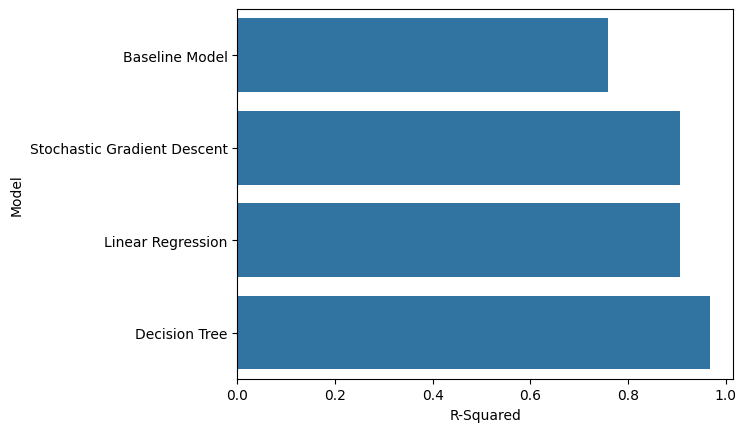

In [29]:
model_scores_df = pd.DataFrame(model_scores)

sns.barplot(
    data=model_scores_df.sort_values(by='R-Squared'),
    y='Model',
    x='R-Squared'
)

Based on the R-squared scores provided, the decision tree model stands out as the best performer. A higher R-squared score indicates that the model can explain a larger proportion of the variance in the labels (y) based on the features (X); meaning it can better capture the underlying relationships between the predictor features and the target feature, resulting in more accurate predictions.

---
## 7.&nbsp;Assessing a regression model manually 👀
Beyond examining the individual output metrics from Scikit-Learn, we can gain deeper insights by visualising the calculated differences and plotting them. This approach allows us to evaluate the performance of our regression model more comprehensively.

### 7.1.&nbsp;Histogram of errors
By examining the histogram, we can assess if the errors follow a normal distribution, detect outliers, and identify any skewed data, ultimately aiding us in refining our model and addressing potential issues.

#### 7.1.1.&nbsp; Histogram of errors - baseline model
To construct the histogram, we begin by computing the errors. We expand our test set with two columns: the actual price and the predicted price. By examining the difference between these columns, we can evaluate the errors made by our model.

In [30]:
test_data = X_test.copy()
test_data['price'] = y_test

In [31]:
baseline_model_errors_df = test_data.copy()
baseline_model_errors_df["prediction"] = baseline_test_pred
baseline_model_errors_df["error"] = baseline_model_errors_df["prediction"] - baseline_model_errors_df["price"]

In [32]:
baseline_model_errors_df

,carat,cut,color,clarity,depth,table,x,y,z,price,prediction,error
1388,0.24,Ideal,G,VVS1,62.1,56.0,3.97,4.00,2.47,559,1440.0,881.0
50052,0.58,Very Good,F,VVS2,60.0,57.0,5.44,5.42,3.26,2201,3480.0,1279.0
41645,0.40,Ideal,E,VVS2,62.1,55.0,4.76,4.74,2.95,1238,2400.0,1162.0
42377,0.43,Premium,E,VVS2,60.8,57.0,4.92,4.89,2.98,1304,2580.0,1276.0
17244,1.55,Ideal,E,SI2,62.3,55.0,7.44,7.37,4.61,6901,9300.0,2399.0
...,...,...,...,...,...,...,...,...,...,...,...,...
44081,0.50,Very Good,E,VS1,61.6,59.0,5.06,5.14,3.14,1554,3000.0,1446.0
23713,0.25,Very Good,F,VVS2,61.6,57.0,4.05,4.07,2.50,633,1500.0,867.0
31375,0.31,Good,G,VVS1,58.0,62.0,4.42,4.47,2.58,761,1860.0,1099.0
21772,1.23,Ideal,F,VS1,62.5,54.0,6.85,6.82,4.27,9836,7380.0,-2456.0


Now that we have the error calculated for each row we can plot it.

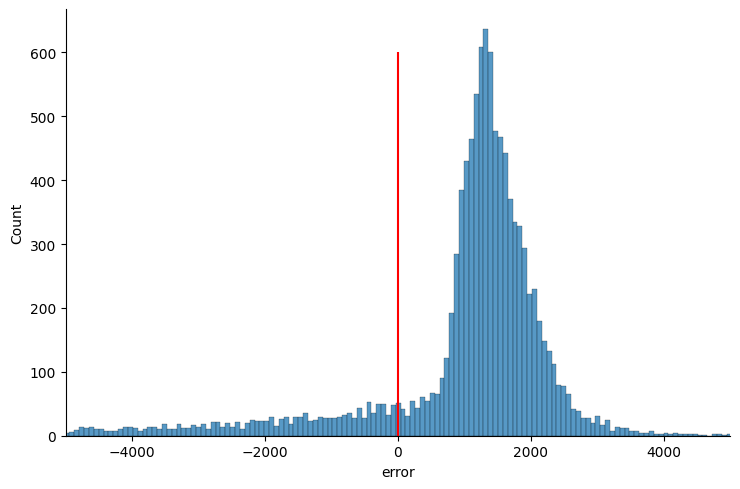

In [33]:
sns.displot(
    baseline_model_errors_df['error'],
    aspect=1.5
)
plt.vlines(
    x=0,
    ymin=0,
    ymax=600,
    color='red'
)

plt.xlim(-5000, 5000)
plt.show()

Our baseline model's predictions exhibit a left-skewed distribution, indicating a consistent tendency to underpredict the diamond prices. Specifically, there is a prominent peak on the right-hand side, where the model frequently underestimates the price by approximately $1700.

#### 7.1.2.&nbsp;Histogram of errors - decision tree model

In [34]:
dt_errors_df = test_data.copy()
dt_errors_df["prediction"] = dt_predictions
dt_errors_df["error"] = dt_errors_df["prediction"] - dt_errors_df["price"]

In [35]:
dt_errors_df

,carat,cut,color,clarity,depth,table,x,y,z,price,prediction,error
1388,0.24,Ideal,G,VVS1,62.1,56.0,3.97,4.00,2.47,559,559.0,0.0
50052,0.58,Very Good,F,VVS2,60.0,57.0,5.44,5.42,3.26,2201,2321.0,120.0
41645,0.40,Ideal,E,VVS2,62.1,55.0,4.76,4.74,2.95,1238,1238.0,0.0
42377,0.43,Premium,E,VVS2,60.8,57.0,4.92,4.89,2.98,1304,1135.0,-169.0
17244,1.55,Ideal,E,SI2,62.3,55.0,7.44,7.37,4.61,6901,8631.0,1730.0
...,...,...,...,...,...,...,...,...,...,...,...,...
44081,0.50,Very Good,E,VS1,61.6,59.0,5.06,5.14,3.14,1554,1849.0,295.0
23713,0.25,Very Good,F,VVS2,61.6,57.0,4.05,4.07,2.50,633,575.0,-58.0
31375,0.31,Good,G,VVS1,58.0,62.0,4.42,4.47,2.58,761,642.0,-119.0
21772,1.23,Ideal,F,VS1,62.5,54.0,6.85,6.82,4.27,9836,9660.0,-176.0


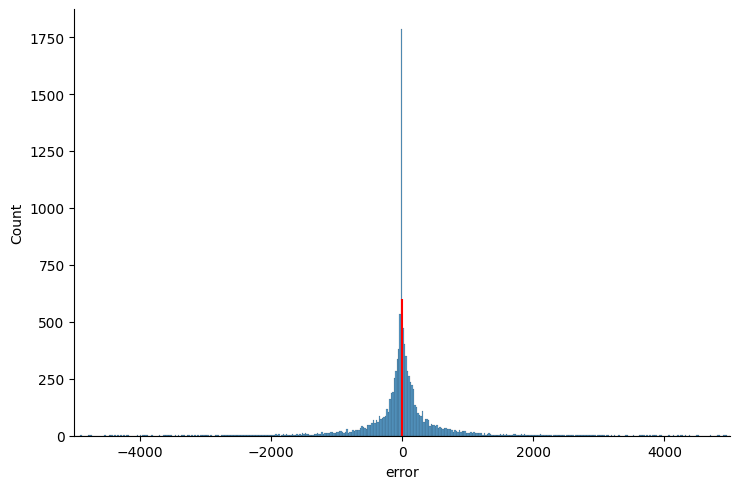

In [36]:
sns.displot(dt_errors_df['error'],
            aspect=1.5)
plt.vlines(x=0,
           ymin=0,
           ymax=600,
           color='red')
plt.xlim(-5000,
         5000)
plt.show()

We can see from our decision tree model that it is much more even handed in its over- and underestimation of the price. Also, there are significantly less large errors here compared to the baseline model.

### 7.2.&nbsp;Scatterplot of errors
A scatterplot can help guide us in a similar manner to a histogram

#### 7.2.1.&nbsp; Scatterplot of errors - baseline model

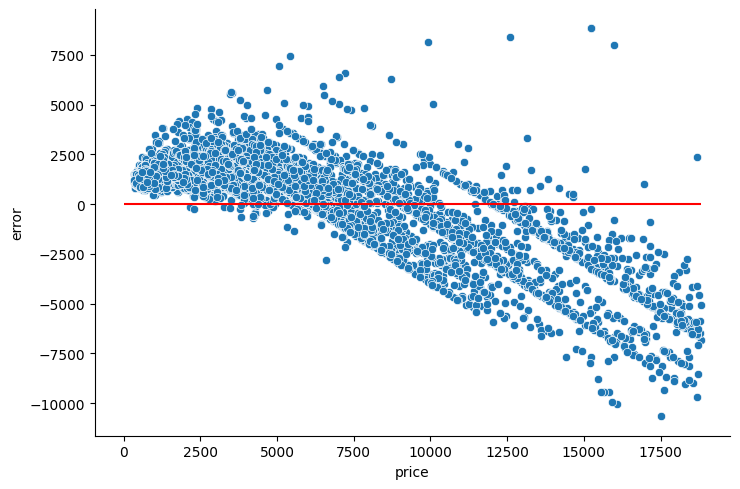

In [37]:
sns.relplot(data=baseline_model_errors_df,
            x='price',
            y='error',
            aspect=1.5)
plt.hlines(y=0,
           xmin=0,
           xmax=max(baseline_model_errors_df['price']),
           color='red')
plt.show()

We can see that the more expensive the diamonds become, the worse our model is at predicting the price.

#### 7.2.2.&nbsp;Scatterplot of errors - decision tree model

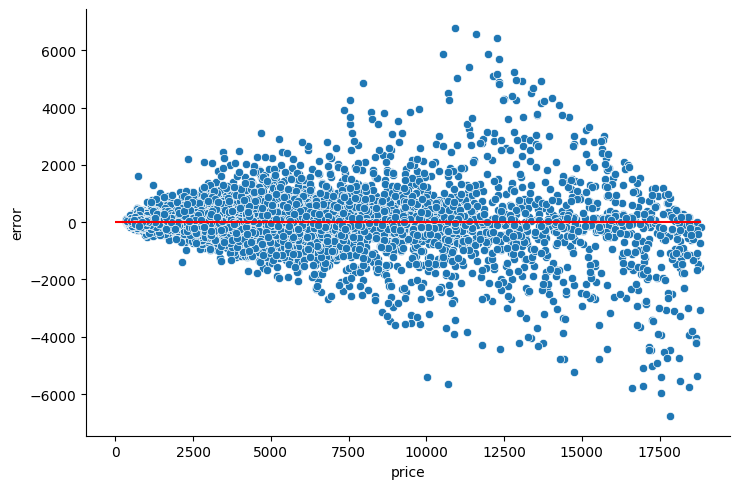

In [38]:
sns.relplot(data=dt_errors_df,
            x='price',
            y='error',
            aspect=1.5)
plt.hlines(y=0,
           xmin=0,
           xmax=max(dt_errors_df['price']),
           color='red')
plt.show()

From the y-axis range, it is evident that the decision tree performs better in predicting the price overall. The increased symmetry in the plot indicates that the model is not solely overpredicting or underpredicting, showing a balanced performance. However, the model still struggles with predicting prices for expensive diamonds. This gives us more information that the scores did: now we know that we should be less confident in the model's predictions the more expensive the diamond is.